In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/modified_data.csv")
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)


Shape: (4600, 18)

Column names:
['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'price_per_sqft']

Data types:
date                  str
price             float64
bedrooms          float64
bathrooms         float64
sqft_living         int64
sqft_lot            int64
floors            float64
waterfront          int64
view                int64
condition           int64
sqft_above          int64
sqft_basement       int64
yr_built            int64
yr_renovated        int64
street                str
city                  str
statezip              str
price_per_sqft    float64
dtype: object


In [ ]:
print("Null counts:")
print(df.isnull().sum())

print("\nUnique-value counts:")
print(df.nunique())
# No missing values were found, so no imputation or row removal is needed.

Null counts:
date              0
price             0
bedrooms          0
bathrooms         0
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
street            0
city              0
statezip          0
price_per_sqft    0
dtype: int64

Unique-value counts:
date                70
price             1741
bedrooms            10
bathrooms           26
sqft_living        566
sqft_lot          3113
floors               6
waterfront           2
view                 5
condition            5
sqft_above         511
sqft_basement      207
yr_built           115
yr_renovated        60
street            4525
city                44
statezip            77
price_per_sqft    4005
dtype: int64


### Dataset Information

- **Dataset:** House Price Prediction
- **Source:** Kaggle
- **Source URL:** https://www.kaggle.com/datasets/debayank2024/house-price-prediction
- **License:**
- **Why I chose it:** I chose this dataset because it contains information about houses and their prices, including both numerical and categorical features. It is suitable for practicing data cleaning, data analysis, and feature engineering.

In [ ]:
df["date"] = pd.to_datetime(df["date"])

print(df.dtypes)

date              datetime64[us]
price                    float64
bedrooms                 float64
bathrooms                float64
sqft_living                int64
sqft_lot                   int64
floors                   float64
waterfront                 int64
view                       int64
condition                  int64
sqft_above                 int64
sqft_basement              int64
yr_built                   int64
yr_renovated               int64
street                       str
city                         str
statezip                     str
price_per_sqft           float64
dtype: object


In [ ]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# No duplicate rows were found, so no rows were removed.

Number of duplicate rows: 0


In [ ]:
print("Shape before GroupBy:", df.shape)

Shape before GroupBy: (4600, 18)


In [ ]:
city_stats = df.groupby("city").agg(
    average_price=("price", "mean"),
    house_count=("price", "count")
).reset_index()

print(city_stats.head())

                 city  average_price  house_count
0              Algona  207288.000000            5
1              Auburn  299340.442784          176
2  Beaux Arts Village  745000.000000            1
3            Bellevue  847180.662972          286
4       Black Diamond  339605.555556            9


In [ ]:
print("Shape before merging city statistics:", df.shape)
df = df.merge(city_stats, on="city", how="left")

print("Shape after merging city statistics:", df.shape)

Shape before merging city statistics: (4600, 18)
Shape after merging city statistics: (4600, 20)


In [ ]:
print("Shape before pivot:", df.shape)
city_bedroom_prices = df.pivot_table(
    values="price",
    index="city",
    columns="bedrooms",
    aggfunc="mean"
)

print(city_bedroom_prices.head())
print("Shape after pivot:", city_bedroom_prices.shape)

Shape before pivot: (4600, 20)
bedrooms            0.0       1.0            2.0            3.0  \
city                                                              
Algona              NaN       NaN  100000.000000  213220.000000   
Auburn              NaN  115000.0  245892.307692  269467.709529   
Beaux Arts Village  NaN       NaN            NaN  745000.000000   
Bellevue            NaN       NaN  808300.000000  667054.338137   
Black Diamond       NaN       NaN  398000.000000  295390.000000   

bedrooms                      4.0           5.0       6.0        7.0  8.0  9.0  
city                                                                            
Algona              255000.000000           NaN       NaN        NaN  NaN  NaN  
Auburn              347037.139420  3.364000e+05  280000.0   280000.0  NaN  NaN  
Beaux Arts Village            NaN           NaN       NaN        NaN  NaN  NaN  
Bellevue            921050.190960  1.039571e+06  851375.0  1119500.0  NaN  NaN  
Black Diamond

In [ ]:
price_array = df["price"].to_numpy()

print(price_array[:10])

[ 313000. 2384000.  342000.  420000.  550000.  490000.  335000.  482000.
  452500.  640000.]


In [ ]:
price_mean = np.mean(price_array)
price_std = np.std(price_array)

print("Mean price:", price_mean)
print("Standard deviation:", price_std)

Mean price: 551962.9884695652
Standard deviation: 563773.4128327755


In [ ]:
price_zscore = (price_array - price_mean) / price_std

print(price_zscore[:10])

[-0.42386353  3.2495981  -0.37242442 -0.23407097 -0.00348187 -0.10990761
 -0.38484076 -0.12409771 -0.17642369  0.15615673]


In [ ]:
print("Mean of z-scores:", np.mean(price_zscore))
print("Standard deviation of z-scores:", np.std(price_zscore))
print("Minimum z-score:", np.min(price_zscore))
print("Maximum z-score:", np.max(price_zscore))

Mean of z-scores: 8.032222230331568e-17
Standard deviation of z-scores: 0.9999999999999999
Minimum z-score: -0.9790511150501637
Maximum z-score: 46.18528724279119


In [ ]:
df["price_zscore"] = price_zscore

print(df[["price", "price_zscore"]].head())

       price  price_zscore
0   313000.0     -0.423864
1  2384000.0      3.249598
2   342000.0     -0.372424
3   420000.0     -0.234071
4   550000.0     -0.003482


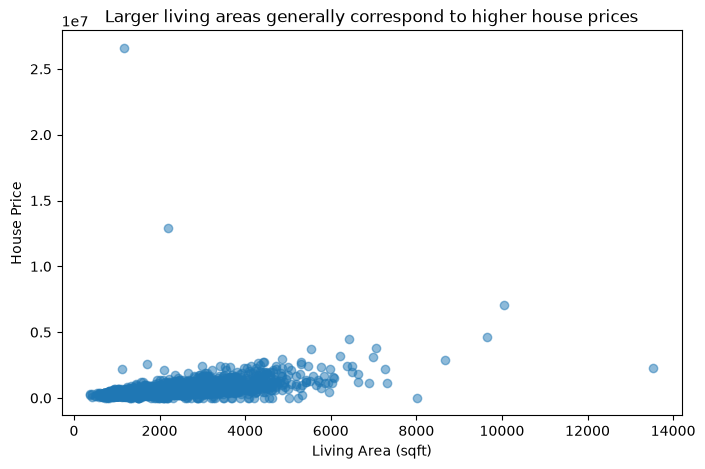

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df["sqft_living"], df["price"], alpha=0.5)

plt.xlabel("Living Area (sqft)")
plt.ylabel("House Price")
plt.title("Larger living areas generally correspond to higher house prices")

plt.savefig("../reports/a2_chart1.png", dpi=150, bbox_inches="tight")

plt.show()

In [3]:
bedroom_prices = df.groupby("bedrooms")["price"].mean()

print(bedroom_prices)

bedrooms
0.0    1.195324e+06
1.0    2.740763e+05
2.0    3.916219e+05
3.0    4.886130e+05
4.0    6.351194e+05
5.0    7.701860e+05
6.0    8.173628e+05
7.0    1.049429e+06
8.0    1.155000e+06
9.0    5.999990e+05
Name: price, dtype: float64


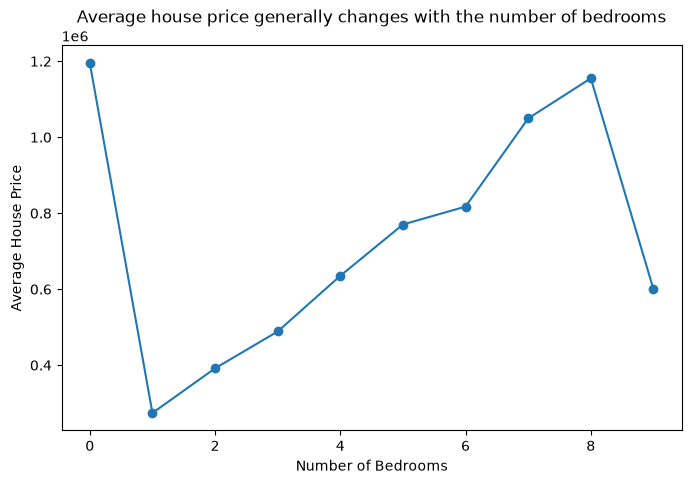

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(bedroom_prices.index, bedroom_prices.values, marker="o")

plt.xlabel("Number of Bedrooms")
plt.ylabel("Average House Price")
plt.title("Average house price generally changes with the number of bedrooms")

plt.savefig("../reports/a2_chart2.png", dpi=150, bbox_inches="tight")

plt.show()

# Task 5: Exploratory Visualization

I created two visualizations to explore relationships between house characteristics and prices.